In [78]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [79]:
path

'/kaggle/input/brain-tumor-mri-dataset'

In [80]:
! cp -r /kaggle/input/brain-tumor-mri-dataset /content/Brain_Tumor

In [107]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from pathlib import Path

In [82]:
train_path = r"/content/Brain_Tumor/Training"
test_path =  r"/content/Brain_Tumor/Testing"

## Split The Data

In [83]:
img_size = (224,224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    image_size=img_size,
    batch_size=batch_size,
    seed=seed)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split= 0.2,
    subset= "validation",
    image_size= img_size,
    batch_size= batch_size,
    seed= seed
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size= img_size,
    batch_size = batch_size,
    shuffle=False
)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [84]:
print("Number of classes: ", len(train_ds.class_names))
print("Class Names:", train_ds.class_names)

Number of classes:  4
Class Names: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Autotune

In [85]:
Autotune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=Autotune)
validation_ds = validation_ds.cache().prefetch(buffer_size=Autotune)
test_ds = test_ds.cache().prefetch(buffer_size=Autotune)

## Build The Model

In [86]:
# Augmenation

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.1)
])

In [87]:
# Model Layers

model = models.Sequential([
    layers.InputLayer(shape=(224,224,3)),

    augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

In [88]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,884 (37.49 MB)

 Trainable params: 9,826,884 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
early_Stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=validation_ds,
    callbacks=[early_Stopping],
    verbose=1
    )


Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.5455 - loss: 1.0428 - val_accuracy: 0.7545 - val_loss: 0.7005
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7045 - loss: 0.7198 - val_accuracy: 0.8116 - val_loss: 0.4828
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7574 - loss: 0.6015 - val_accuracy: 0.7125 - val_loss: 0.7603
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.7719 - loss: 0.5781 - val_accuracy: 0.8411 - val_loss: 0.4232
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.7946 - loss: 0.5041 - val_accuracy: 0.8795 - val_loss: 0.3610
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8199 - loss: 0.4728 - val_accuracy: 0.8643 - val_loss: 0.3391
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8364 - loss: 0.4149 - val_accuracy: 0.8321 - val_loss: 0.4106
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8431 - loss: 0.3973 - val_acc

## Evaluation

In [109]:
loss , acc = model.evaluate(test_ds)
print("Accuracy: ", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9187 - loss: 0.9406
Accuracy:  0.918749988079071


In [110]:
import numpy as np

img_path = "/content/Brain_Tumor/Testing/meningioma/Te-aug-me_20.jpg"
img_size = (224,224)

image = tf.keras.utils.load_img(
    img_path,
    target_size=img_size
)

img_arr = tf.keras.utils.img_to_array(image)
img_arr = np.expand_dims(img_arr,axis=0)

In [111]:
prediction = model.predict(img_arr)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[6.5534558e-05 9.6654332e-01 3.3390705e-02 4.7772988e-07]]


## Sample Prediction

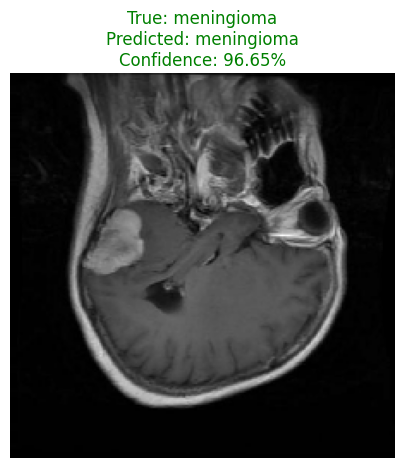

In [112]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

prediction_index = np.argmax(prediction)
predicted_class = class_names[prediction_index]

confidence = prediction[0][prediction_index] * 100

# True Label
true_label = Path(img_path).parent.name

# Display
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

color = "green" if predicted_class == true_label else "red"

plt.title(
    f"True: {true_label}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%",
    color=color,
    fontsize=12
)

plt.show()

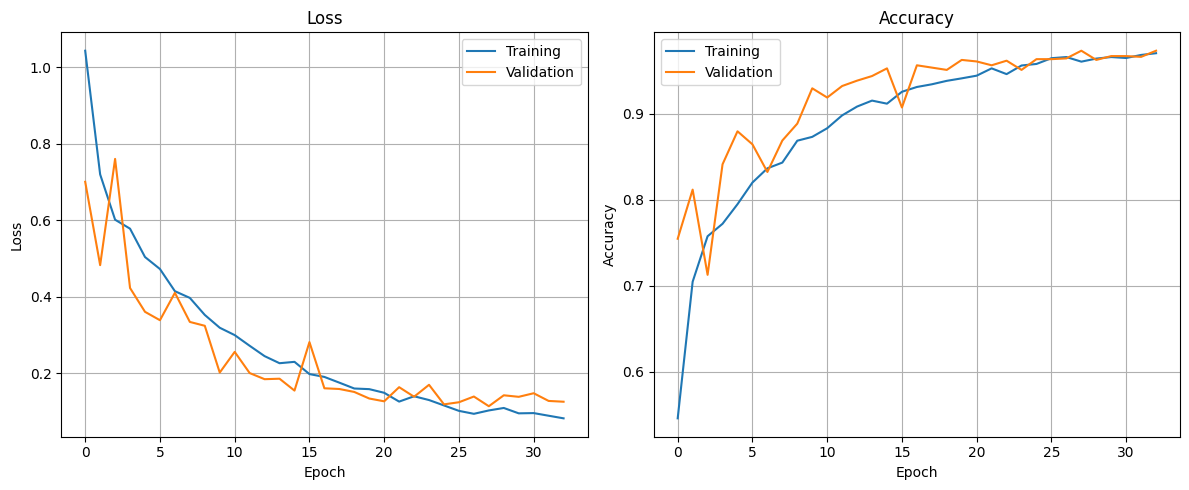

In [113]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


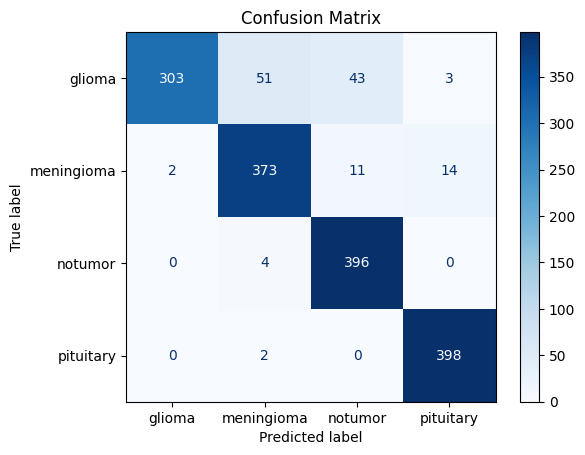

In [114]:
# Confusion Matrix

# Predictions
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

# True Labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [115]:

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.99      0.76      0.86       400
  meningioma       0.87      0.93      0.90       400
     notumor       0.88      0.99      0.93       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [97]:
model.save("Brain_Tumor_MRI.keras")